### Invariant of neural representation

- build multivariate gaussian distribution with covariance matrix
- The covariance matrix is built by rotating the original covariance matrix
- The rotation is done by a design matrix B.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from sklearn.decomposition import PCA
from hebbian.utils import rotation_matrix_nd, rotate_cov_nd, eig_sorted, ellipse_xy_from_cov, instantiate_before_after_X, before_after_distribution

In [2]:
N = 64
m = 2
phi_deg = 45.0
n_samples = 10001
X_seed = 0
# get /sigma
Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
# Sigma = np.array([[1.0, 0.2, 0.2, 0.5], [0.2, 1.0, 0.2, 0.5], [0.2, 0.2, 1.0, 0.5], [0.5, 0.5, 0.5, 1.0]])
Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)

# Do PCA on X before and X after
pca_before = PCA(n_components=m)
pca_before.fit(X_before)
X_before_pca = pca_before.transform(X_before)
pca_after = PCA(n_components=m)
pca_after.fit(X_after)
X_after_pca = pca_after.transform(X_after)

# eigen values of X before and X after
print(f"Eigen values of X before: {pca_before.explained_variance_}")
print(f"Eigen values of X after: {pca_after.explained_variance_}")

# variance explained by each PC
print(f"Variance explained by each PC of X before: {pca_before.explained_variance_ratio_}")
print(f"Variance explained by each PC of X after: {pca_after.explained_variance_ratio_}")



Eigen values of X before: [1.18832136 0.79510762]
Eigen values of X after: [1.22674947 0.80661225]
Variance explained by each PC of X before: [0.59912473 0.40087527]
Variance explained by each PC of X after: [0.60331099 0.39668901]


### Apply Leen's complete model to before and after drifted models

In [3]:
from hebbian.models import OneShotLeenCompletePCA, OneShotLeenReislebenPCA
from hebbian.utils import Y_aligned_training_testing, Y_aligned_training_testing_online

### Multiple runs

In [4]:
### Two phase training and testing

def bar_graph_with_error_bars(df_best_corr, title):
    figure = plt.figure()
    means = df_best_corr.mean(axis=0)
    stds = df_best_corr.std(axis=0)
    plt.figure(figsize=(10, 6))
    plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
    plt.ylabel('Mean Absolute Correlation')
    plt.title(title)
    plt.show()

def two_phase_training_testing(model, data_before, data_after, m, model_paras_after=None, runs =10, graph = True):
    df_best_corr_after = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    df_best_corr_before = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])

    for run in range(runs):
        print(f"run {run+1:2d}")
        print(f"X_before")
        order, similarity = Y_aligned_training_testing_online(model, data_before, graph=True, alignment="cov")
        # print(f"After first phase: model.W = {model.W}, model.V: {model.V}")
        print(f"W after first phase: {model.W}")
        # print(f"Y_output_after_first_phase: {model.transform(data_before)}")
       # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_before.iloc[run, :] = ordered_similarity 

#################################################################
        print(f"X_after")
        # update the model parameters, if provided
        if model_paras_after is not None:
            for key, value in model_paras_after.items():
                if hasattr(model, key):
                    setattr(model, key, value)

        order, similarity = Y_aligned_training_testing_online(model, data_after, graph=True, alignment="cosine")
        print(f"after second phase: model.W = {model.W}")
        try:
            print(f"model.V = {model.V}")
        except AttributeError:
            pass
        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_after.iloc[run, :] = ordered_similarity
        # print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")
        model.reset()

    if graph == True:
        bar_graph_with_error_bars(df_best_corr_before, "Mean Absolute Correlation (before)")
        bar_graph_with_error_bars(df_best_corr_after, "Mean Absolute Correlation (after)")

### Golden standard: Sanger's rule

In [ ]:
from hebbian.models import SangerNetwork
sanger_model = SangerNetwork(output_size=m, learning_rate=0.011, rng=None)

sanger_model_after = dict(learning_rate=0.01)

two_phase_training_testing(sanger_model, X_before, X_after, m, model_paras_after = sanger_model_after, runs = 10, graph = True)

### Leen's complete model

In [5]:
# runs = 10
model_paras = dict(
    input_dim=N, output_dim=m,
    eta_w=5e-3,          # base
    eta_v=5e-2,          # ~4x eta_w
    C=1.5,
    # ema_alpha=0.03,
    symmetrize_V=True,
    seed=None,
    noise_level=0.001,
    # settling_steps=10
)

model_paras_after = dict(
    eta_w=5e-3,
    eta_v=5e-2,
    C=1.5,
#     eta_w=6e-5,          # base
#     eta_v=5e-4,          # ~4x eta_w
)

In [ ]:
leen_model  = OneShotLeenCompletePCA(**model_paras)

leen_model = OneShotLeenReislebenPCA(**model_paras)

two_phase_training_testing(leen_model, X_before, X_after, m, model_paras_after = model_paras_after, runs = 10, graph = True)

### decoding task variable

In [77]:
from hebbian.utils import pca_topk, best_match_align_eigenvectors
from hebbian.models import SangerNetwork, OneShotLeenReislebenPCA
### caicluate the task variable across time

# generate values between 0 and 1 for m number
rng_para = np.random.default_rng(seed=42)
params = rng_para.random(m)
batch_size = 1
model = SangerNetwork(output_size=m, learning_rate=0.01)
# model = OneShotLeenReislebenPCA(**model_paras)


# get the weighted sum of the PC scores across all samples, using X_before
pcs, _, scores = pca_topk(X_before, k=m)
# calculate the task variable across time
task_var = np.dot(scores, params)

for step in range(0, n_samples, batch_size):
    if step == 1:
        print(f"before training: {model.W}")
    X_train = X_before[step:step+batch_size]
    model.step(X_train)
    # use the X_mask to incrementally reveal the input matrix, and update the model

Y_output = model.transform(X_before)
# get the best match alignment between Y_output and PC_scores by hungarian algorithm
try:
    V = model.V
except:
    V = None

print(f"after training: {model.W}")

order, sim, _ = best_match_align_eigenvectors(model.W, V=V, eigenvectors=pcs)
print(order, sim)
task_var_tilde = np.dot(Y_output[:, order], params)



before training: [[ 3.98719898e-03  2.04112333e-03  8.22328361e-03 -1.44852034e-02
  -4.05125365e-03  1.00216620e-02  4.26956740e-03  2.11426877e-03
  -2.87901530e-03  4.53566531e-03  5.86198280e-03  1.29756367e-02
   1.22924957e-03 -7.57480724e-03  1.80885156e-03 -6.54157974e-03
   5.08429358e-03 -1.06832853e-02  3.33596885e-03  3.61442297e-03
   9.65474412e-03 -1.57043926e-03  2.72502714e-03  1.41760527e-02
  -8.13095540e-03  3.56318110e-04 -1.37515414e-03  2.10417747e-03
   2.27742535e-03 -7.96425300e-03 -1.62397776e-02  5.09640637e-03
  -1.88125242e-02  8.62086844e-04 -1.63989103e-02 -3.06316746e-04
   7.06190728e-03  9.68634513e-04 -3.57876254e-03  7.02571828e-03
   7.68572305e-03 -6.68114907e-03 -8.02791514e-03 -3.40049029e-03
  -1.17487364e-02  1.01756439e-02  1.03819449e-02 -7.32116099e-03
   2.84102671e-02  2.57088989e-02 -7.91375426e-03 -1.43457899e-03
  -6.73121551e-05 -5.44895502e-03  1.38006489e-04  5.44877374e-03
   1.54496353e-03  5.25903243e-03 -6.66979347e-03  3.929889

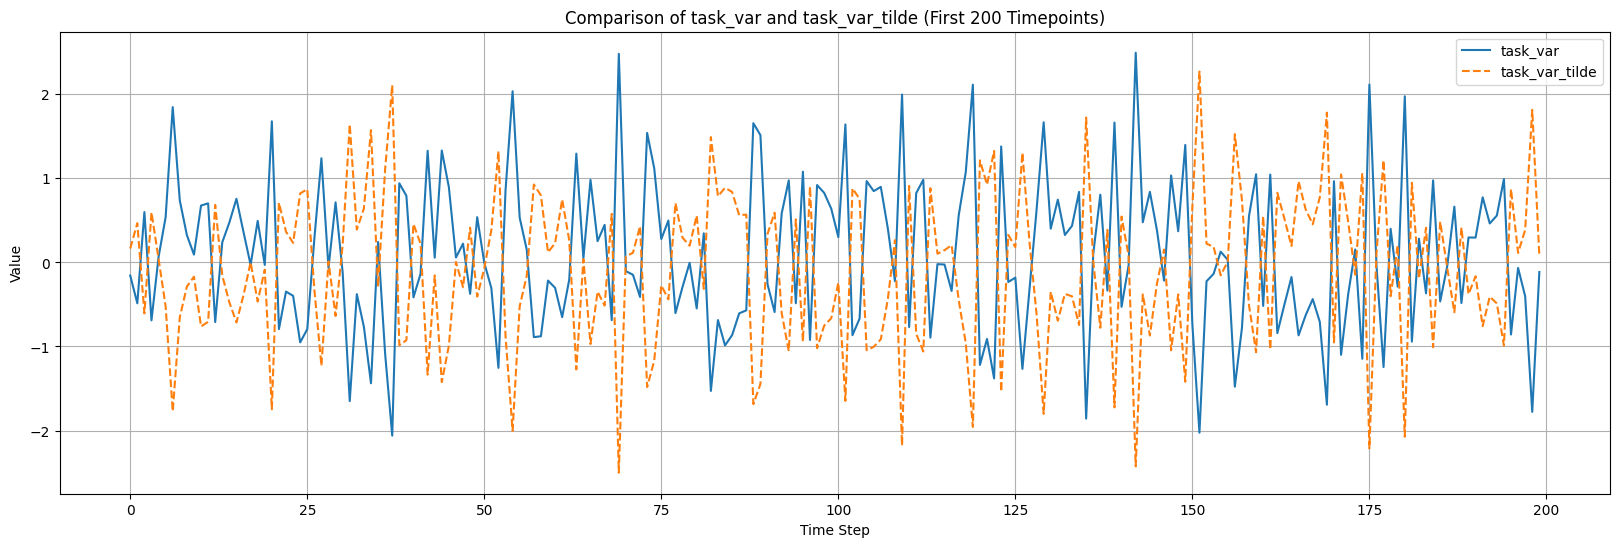

3.4961773898940405


In [78]:
# visualize
plt.figure(figsize=(20, 6))
plt.plot(task_var[:200], label='task_var')
plt.plot(task_var_tilde[:200], label='task_var_tilde', linestyle='--')
plt.xlabel('Time Step') # Assuming an underlying time or step index
plt.ylabel('Value')
plt.title('Comparison of task_var and task_var_tilde (First 200 Timepoints)')
plt.legend()
plt.grid(True)
plt.show()

# get MSE
mse = np.mean((task_var - task_var_tilde)**2)
print(mse)

### Chance level exploration with random vectors

In [ ]:
from hebbian.utils import pca_topk
from scipy.stats import pearsonr
from hebbian.utils import best_match_align_timeseries



def random_projection_chance_corr1(X, n_samples=1000, seed=None):
    """
    Calculate the expected absolute correlation between a random projection 
    of X and the PC projections of X.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    n_samples : int, default=1000
        Number of random vectors to sample for Monte Carlo estimation
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation between random projection and PC projections
    std_corr : float
        Standard deviation of correlations (for reference)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PCs
    _, _, PC_scores = pca_topk(X, d, center=True)
    print(f"shape of PC_scores: {PC_scores.shape}")
    
    # Sample random unit vectors
    rng = np.random.default_rng(seed)
    correlations = []
    
    for _ in range(n_samples):
        # Random unit vector in d-dimensional space
        w = rng.normal(size=d)
        w = w / (np.linalg.norm(w) + 1e-12)
        
        # Project X onto random direction
        y_random = Xc @ w
        
        # Compute correlation with each PC
        pc_corrs = []
        # print(f"shape of y_random: {y_random.shape}")
        
        # for j in range(min(d, PC_scores.shape[1])):
        # for j in range(2):
        # calculate the covariance between y_random and PC_scores[:, 0]
        cov = np.cov(y_random, PC_scores[:, 0])/np.cov(PC_scores[:, 0], PC_scores[:, 0])
        # pc_corrs.append(abs(r))
        pc_corrs.append(abs(cov[0, 1]))

        
        # Take max correlation (best match, like Hungarian algorithm does)
        correlations.append(max(pc_corrs))
    
    return np.mean(correlations), np.std(correlations)


def random_projection_chance_corr(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Calculate the expected absolute correlation between random projections 
    of X and the PC projections of X, using the same matching procedure
    as the actual analysis (best_match_align_timeseries).
    
    This generates m random unit vectors, projects X onto them, and uses
    Hungarian matching to find optimal alignment with PCs, just like the
    real analysis does.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    m : int, default=2
        Number of random projections (should match output_dim of your model)
    n_samples : int, default=1000
        Number of random vector sets to sample for Monte Carlo estimation
    metric : {"corr", "cosine"}, default="corr"
        Metric to use (should match what you use in best_match_align_timeseries)
    absolute : bool, default=True
        Whether to use absolute correlations (should match your usage)
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation after optimal matching
    std_corr : float
        Standard deviation of correlations (for reference)
    all_corrs : ndarray, shape (n_samples, m)
        All correlation values from each trial (for distribution analysis)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PC scores (top m PCs)
    _, _, PC_scores = pca_topk(X, d, center=True)
    PC_scores_m = PC_scores[:, :m]  # Use only top m PCs
    
    # Sample random projections
    rng = np.random.default_rng(seed)
    all_similarities = []
    
    for trial in range(n_samples):
        # Generate m random unit vectors in d-dimensional space
        W_random = rng.normal(size=(m, d))
        # Normalize each row to unit length
        W_random = W_random / (np.linalg.norm(W_random, axis=1, keepdims=True) + 1e-12)
        
        # Project X onto random directions: Y_random = Xc @ W_random.T
        # Shape: (n, d) @ (d, m) = (n, m)
        Y_random = Xc @ W_random.T
        
        # Use the same matching procedure as actual analysis
        perm, similarity, _, _ = best_match_align_timeseries(
            Y_random, PC_scores_m, 
            metric=metric, 
            absolute=absolute
        )
        
        # similarity is already the matched correlations
        all_similarities.append(similarity)
    
    all_similarities = np.array(all_similarities)  # Shape: (n_samples, m)
    
    # Compute statistics
    expected_corr = np.mean(all_similarities)
    std_corr = np.std(all_similarities)
    
    return expected_corr, std_corr, all_similarities


def random_projection_chance_corr_per_pc(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Same as random_projection_chance_corr but returns per-PC statistics.
    
    Returns
    -------
    expected_corr_per_pc : ndarray, shape (m,)
        Expected correlation for each PC (after sorting by PC order)
    std_corr_per_pc : ndarray, shape (m,)
        Standard deviation for each PC
    """
    expected_corr, std_corr, all_similarities = random_projection_chance_corr(
        X, m, n_samples, metric, absolute, seed
    )
    
    # Sort similarities by PC order (they're already matched, but we want PC1, PC2, ...)
    # The similarities are already optimally matched, so we sort them
    all_similarities_sorted = np.sort(all_similarities, axis=1)  # Sort each row
    
    expected_corr_per_pc = np.mean(all_similarities_sorted, axis=0)
    std_corr_per_pc = np.std(all_similarities_sorted, axis=0)
    
    return expected_corr_per_pc, std_corr_per_pc, all_similarities_sorted



def analytical_chance_corr(input_dim):
    """
    Analytical approximation for expected correlation between random projection
    and PC projection, assuming isotropic data (all eigenvalues equal).
    
    This is a simplified case. For non-isotropic data, use random_projection_chance_corr.
    
    Parameters
    ----------
    input_dim : int
        Input dimensionality
        
    Returns
    -------
    float 
        Expected absolute correlation (approximate)
    """
    # For isotropic case, this reduces to the random vector chance level
    # For non-isotropic, it's more complex and depends on eigenvalue distribution
    return np.sqrt(2 / (np.pi * input_dim))

In [ ]:
print(f"Analytical chance correlation: {analytical_chance_corr(N):.3f}")

In [ ]:
from hebbian.utils import generate_covariance_matrix
for i in range(2, 10, 1):
    N = i
    m = 2
    phi_deg = 45.0
    n_samples = 10001
    # get /sigma
    Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
    Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

    X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)
    print(f" input dimension = {N}")
    print(f"shape of X_before: {X_before.shape}")
    # In Y_aligned_training_testing_online or similar:
    expected_corr, std_corr = random_projection_chance_corr1(X_before, n_samples=1000)
    print(f"Expected chance correlation: {expected_corr:.3f} ± {std_corr:.3f}")

In [ ]:
# In your notebook or analysis:

# Or get per-PC statistics
expected_per_pc, std_per_pc, _ = random_projection_chance_corr_per_pc(
    X_before, m=2, n_samples=1000
)
print(f"Expected chance correlation per PC: PC1={expected_per_pc[0]:.3f}, PC2={expected_per_pc[1]:.3f}")